# Global Air Pollution AQI Analysis

## Milestone 1
This notebook includes data cleaning, exploratory data analysis, statistical analysis, baseline modeling, and machine learning classification for overall AQI category.

In [24]:
import pandas as pd

df = pd.read_csv("../data/global_air_pollution_dataset.csv")
df.head()

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


In [25]:
import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from scipy.stats import spearmanr, kruskal

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
DATA_PATH = "../data/global_air_pollution_dataset.csv"

OUTPUT_DIR = "../outputs"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
RESULT_DIR = os.path.join(OUTPUT_DIR, "results")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

RANDOM_STATE = 42

TARGET_ORDER = [
    "Good",
    "Moderate",
    "Unhealthy for Sensitive Groups",
    "Unhealthy",
    "Very Unhealthy",
    "Hazardous"
]

TARGET_MAP = {label: i for i, label in enumerate(TARGET_ORDER)}

In [27]:
df = pd.read_csv(DATA_PATH)

print("Raw shape:", df.shape)
print(df.columns.tolist())
df.head()

Raw shape: (23463, 12)
['Country', 'City', 'AQI Value', 'AQI Category', 'CO AQI Value', 'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category', 'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value', 'PM2.5 AQI Category']


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23463 entries, 0 to 23462
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country             23036 non-null  object
 1   City                23462 non-null  object
 2   AQI Value           23463 non-null  int64 
 3   AQI Category        23463 non-null  object
 4   CO AQI Value        23463 non-null  int64 
 5   CO AQI Category     23463 non-null  object
 6   Ozone AQI Value     23463 non-null  int64 
 7   Ozone AQI Category  23463 non-null  object
 8   NO2 AQI Value       23463 non-null  int64 
 9   NO2 AQI Category    23463 non-null  object
 10  PM2.5 AQI Value     23463 non-null  int64 
 11  PM2.5 AQI Category  23463 non-null  object
dtypes: int64(5), object(7)
memory usage: 2.1+ MB


In [29]:
df.isna().sum()

Country               427
City                    1
AQI Value               0
AQI Category            0
CO AQI Value            0
CO AQI Category         0
Ozone AQI Value         0
Ozone AQI Category      0
NO2 AQI Value           0
NO2 AQI Category        0
PM2.5 AQI Value         0
PM2.5 AQI Category      0
dtype: int64

In [30]:
df.describe(include="all")

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
count,23036,23462,23463.000000,23463,23463.000000,23463,23463.000000,23463,23463.000000,23463,23463.000000,23463
unique,175,23462,NaN,6,NaN,3,NaN,5,NaN,2,NaN,6
top,United States of America,Praskoveya,NaN,Good,NaN,Good,NaN,Good,NaN,Good,NaN,Good
freq,2872,1,NaN,9936,NaN,23460,NaN,21069,NaN,23448,NaN,10208
mean,NaN,NaN,72.010868,NaN,1.368367,NaN,35.193709,NaN,3.063334,NaN,68.519755,NaN
std,NaN,NaN,56.055220,NaN,1.832064,NaN,28.098723,NaN,5.254108,NaN,54.796443,NaN
min,NaN,NaN,6.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN
25%,NaN,NaN,39.000000,NaN,1.000000,NaN,21.000000,NaN,0.000000,NaN,35.000000,NaN
50%,NaN,NaN,55.000000,NaN,1.000000,NaN,31.000000,NaN,1.000000,NaN,54.000000,NaN
75%,NaN,NaN,79.000000,NaN,1.000000,NaN,40.000000,NaN,4.000000,NaN,79.000000,NaN


In [31]:
df = df.drop_duplicates().copy()

text_cols = [
    "Country", "City", "AQI Category",
    "CO AQI Category", "Ozone AQI Category",
    "NO2 AQI Category", "PM2.5 AQI Category"
]

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

df = df.replace({
    "nan": np.nan,
    "None": np.nan,
    "": np.nan
})

df = df[df["AQI Category"].isin(TARGET_ORDER)].copy()

numeric_cols = [
    "AQI Value",
    "CO AQI Value",
    "Ozone AQI Value",
    "NO2 AQI Value",
    "PM2.5 AQI Value"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Shape after cleaning:", df.shape)
df["AQI Category"].value_counts()

Shape after cleaning: (23463, 12)


AQI Category
Good                              9936
Moderate                          9231
Unhealthy                         2227
Unhealthy for Sensitive Groups    1591
Very Unhealthy                     287
Hazardous                          191
Name: count, dtype: int64

In [32]:
pollutant_value_cols = [
    "CO AQI Value",
    "Ozone AQI Value",
    "NO2 AQI Value",
    "PM2.5 AQI Value"
]

pollutant_category_cols = [
    "CO AQI Category",
    "Ozone AQI Category",
    "NO2 AQI Category",
    "PM2.5 AQI Category"
]

df["Dominant Pollutant"] = df[pollutant_value_cols].idxmax(axis=1)
df["Dominant Pollutant"] = df["Dominant Pollutant"].str.replace(" AQI Value", "", regex=False)

for col in pollutant_value_cols:
    short_name = col.replace(" AQI Value", "").replace(".", "").replace(" ", "_").lower()
    df[f"{short_name}_to_total_ratio"] = np.where(
        df["AQI Value"] > 0,
        df[col] / df["AQI Value"],
        0
    )

df["num_hazardous_pollutants"] = (df[pollutant_category_cols] == "Hazardous").sum(axis=1)
df["num_very_unhealthy_pollutants"] = (df[pollutant_category_cols] == "Very Unhealthy").sum(axis=1)
df["num_unhealthy_pollutants"] = (df[pollutant_category_cols] == "Unhealthy").sum(axis=1)

df["target"] = df["AQI Category"].map(TARGET_MAP)

df.head()

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,...,PM2.5 AQI Category,Dominant Pollutant,co_to_total_ratio,ozone_to_total_ratio,no2_to_total_ratio,pm25_to_total_ratio,num_hazardous_pollutants,num_very_unhealthy_pollutants,num_unhealthy_pollutants,target
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,...,Moderate,PM2.5,0.019608,0.705882,0.000000,1.000000,0,0,0,1
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,...,Good,PM2.5,0.024390,0.121951,0.024390,1.000000,0,0,0,0
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,...,Moderate,PM2.5,0.015152,0.590909,0.030303,1.000000,0,0,0,1
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,...,Good,Ozone,0.029412,1.000000,0.000000,0.588235,0,0,0,0
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,...,Good,Ozone,0.000000,1.000000,0.000000,0.272727,0,0,0,0


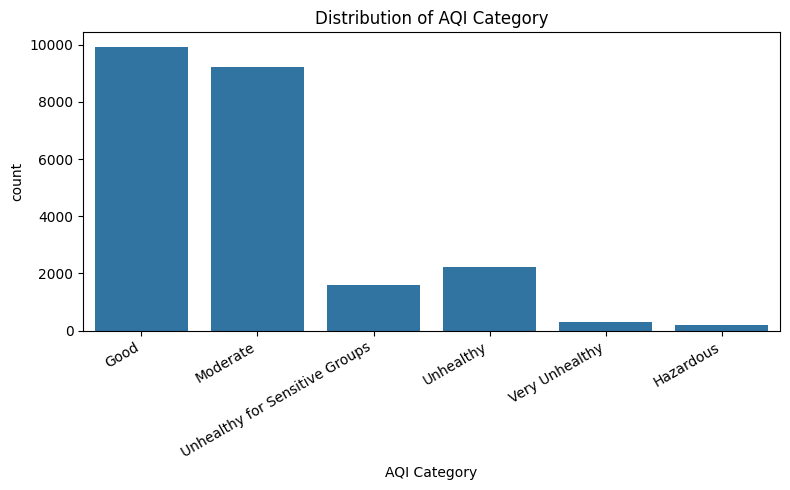

In [33]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="AQI Category", order=TARGET_ORDER)
plt.xticks(rotation=30, ha="right")
plt.title("Distribution of AQI Category")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "aqi_category_distribution.png"), dpi=200)
plt.show()

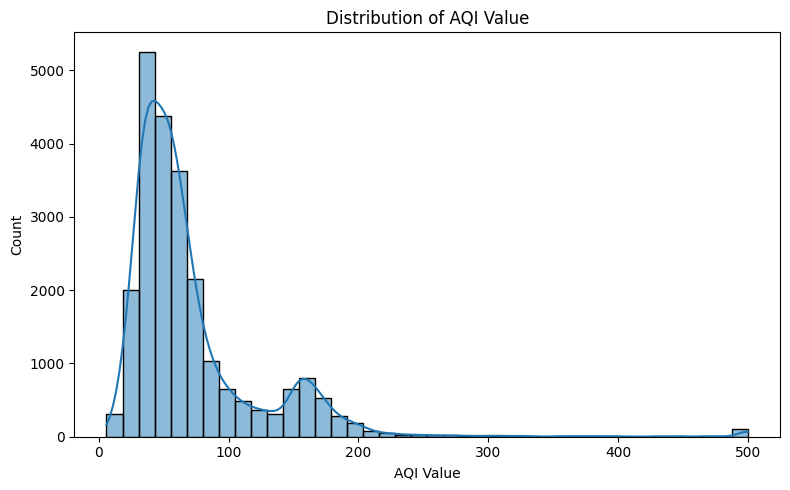

In [34]:
plt.figure(figsize=(8, 5))
sns.histplot(df["AQI Value"].dropna(), bins=40, kde=True)
plt.title("Distribution of AQI Value")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "aqi_value_distribution.png"), dpi=200)
plt.show()

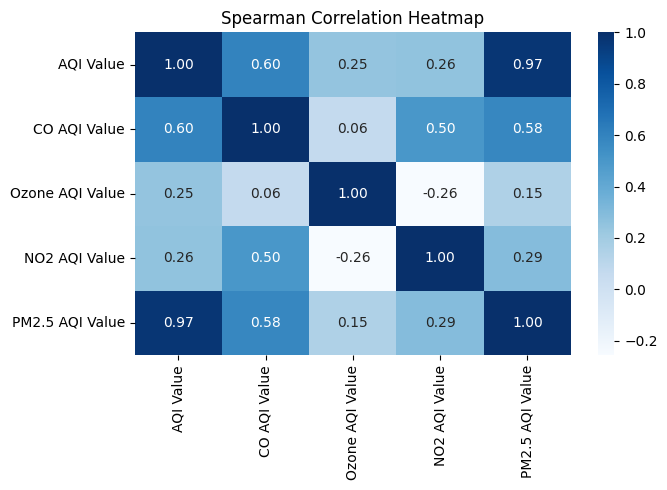

In [35]:
corr_df = df[numeric_cols].corr(method="spearman")

plt.figure(figsize=(7, 5))
sns.heatmap(corr_df, annot=True, cmap="Blues", fmt=".2f")
plt.title("Spearman Correlation Heatmap")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "spearman_heatmap.png"), dpi=200)
plt.show()

In [36]:
spearman_results = {}

for col in pollutant_value_cols:
    temp = df[["AQI Value", col]].dropna()
    rho, pval = spearmanr(temp["AQI Value"], temp[col])
    spearman_results[col] = {"spearman_rho": rho, "p_value": pval}

spearman_results

{'CO AQI Value': {'spearman_rho': 0.6004805144331273, 'p_value': 0.0},
 'Ozone AQI Value': {'spearman_rho': 0.24582592877096326, 'p_value': 0.0},
 'NO2 AQI Value': {'spearman_rho': 0.25785634912601135, 'p_value': 0.0},
 'PM2.5 AQI Value': {'spearman_rho': 0.967899229221191, 'p_value': 0.0}}

In [37]:
top_countries = df["Country"].value_counts().head(5).index.tolist()

country_groups = []
valid_country_names = []

for country in top_countries:
    vals = df.loc[df["Country"] == country, "AQI Value"].dropna().values
    if len(vals) > 0:
        country_groups.append(vals)
        valid_country_names.append(country)

h_stat, h_pval = kruskal(*country_groups)
print("Countries:", valid_country_names)
print("H statistic:", h_stat)
print("p-value:", h_pval)

Countries: ['United States of America', 'India', 'Brazil', 'Germany', 'Russian Federation']
H statistic: 4726.389218777522
p-value: 0.0


In [38]:
rng = np.random.default_rng(RANDOM_STATE)
aqi_values = df["AQI Value"].dropna().values
bootstrap_means = []

for _ in range(2000):
    sample = rng.choice(aqi_values, size=len(aqi_values), replace=True)
    bootstrap_means.append(sample.mean())

ci_lower = np.percentile(bootstrap_means, 2.5)
ci_upper = np.percentile(bootstrap_means, 97.5)

print("Mean AQI:", aqi_values.mean())
print("95% CI:", (ci_lower, ci_upper))

Mean AQI: 72.01086817542513
95% CI: (71.3521363423262, 72.76759685462217)


In [39]:
feature_cols = [
    "Country",
    "City",
    "CO AQI Value",
    "Ozone AQI Value",
    "NO2 AQI Value",
    "PM2.5 AQI Value",
    "Dominant Pollutant"
]

X = df[feature_cols].copy()
y = df["target"].copy()

numeric_features = [
    "CO AQI Value",
    "Ozone AQI Value",
    "NO2 AQI Value",
    "PM2.5 AQI Value"
]

categorical_features = [
    "Country",
    "City",
    "Dominant Pollutant"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape, X_test.shape)

(18770, 7) (4693, 7)


In [40]:
dummy_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

dummy_pipe.fit(X_train, y_train)
y_pred_dummy = dummy_pipe.predict(X_test)

print("Dummy Accuracy:", accuracy_score(y_test, y_pred_dummy))
print("Dummy Macro F1:", f1_score(y_test, y_pred_dummy, average="macro"))
print(classification_report(y_test, y_pred_dummy, target_names=TARGET_ORDER, zero_division=0))

Dummy Accuracy: 0.42339654805028765
Dummy Macro F1: 0.09915169660678642
                                precision    recall  f1-score   support

                          Good       0.42      1.00      0.59      1987
                      Moderate       0.00      0.00      0.00      1846
Unhealthy for Sensitive Groups       0.00      0.00      0.00       318
                     Unhealthy       0.00      0.00      0.00       446
                Very Unhealthy       0.00      0.00      0.00        58
                     Hazardous       0.00      0.00      0.00        38

                      accuracy                           0.42      4693
                     macro avg       0.07      0.17      0.10      4693
                  weighted avg       0.18      0.42      0.25      4693



In [41]:
lr_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression Macro F1:", f1_score(y_test, y_pred_lr, average="macro"))
print(classification_report(y_test, y_pred_lr, target_names=TARGET_ORDER, zero_division=0))

Logistic Regression Accuracy: 0.942680588109951
Logistic Regression Macro F1: 0.9109248269579001
                                precision    recall  f1-score   support

                          Good       0.97      0.95      0.96      1987
                      Moderate       0.94      0.95      0.95      1846
Unhealthy for Sensitive Groups       0.83      0.90      0.86       318
                     Unhealthy       0.92      0.93      0.92       446
                Very Unhealthy       0.78      0.81      0.80        58
                     Hazardous       0.95      1.00      0.97        38

                      accuracy                           0.94      4693
                     macro avg       0.90      0.92      0.91      4693
                  weighted avg       0.94      0.94      0.94      4693



In [42]:
rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Macro F1:", f1_score(y_test, y_pred_rf, average="macro"))
print(classification_report(y_test, y_pred_rf, target_names=TARGET_ORDER, zero_division=0))

Random Forest Accuracy: 0.7116982740251439
Random Forest Macro F1: 0.39362255255059836
                                precision    recall  f1-score   support

                          Good       0.87      0.99      0.92      1987
                      Moderate       0.90      0.65      0.75      1846
Unhealthy for Sensitive Groups       0.29      0.32      0.31       318
                     Unhealthy       0.46      0.05      0.10       446
                Very Unhealthy       0.08      0.40      0.13        58
                     Hazardous       0.08      0.89      0.15        38

                      accuracy                           0.71      4693
                     macro avg       0.45      0.55      0.39      4693
                  weighted avg       0.79      0.71      0.72      4693



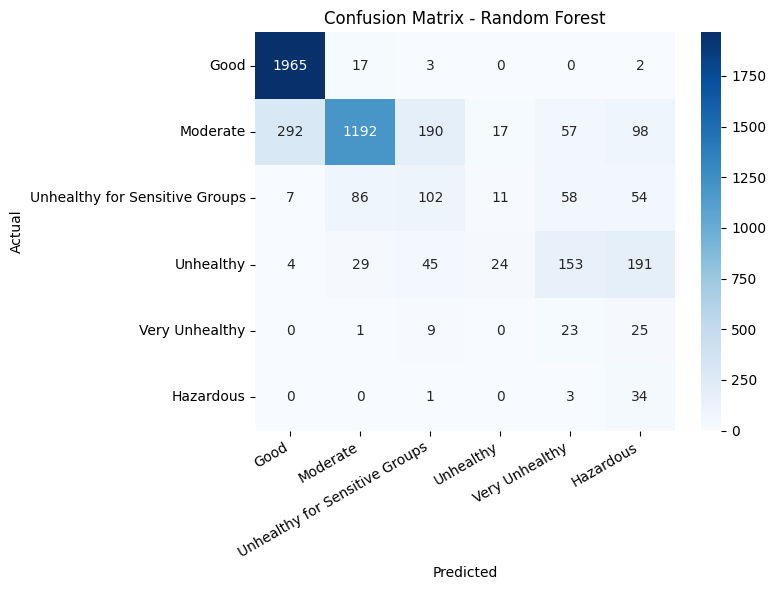

In [43]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=TARGET_ORDER, yticklabels=TARGET_ORDER)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "cm_random_forest.png"), dpi=200)
plt.show()

In [44]:
perm = permutation_importance(
    rf_pipe,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_macro",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

importance_df.head(15)

,feature,importance_mean,importance_std
0,Country,0.087960,0.005622
5,PM2.5 AQI Value,0.083680,0.003978
6,Dominant Pollutant,0.035803,0.004558
2,CO AQI Value,0.016255,0.002901
4,NO2 AQI Value,0.013271,0.002874
1,City,0.000000,0.000000
3,Ozone AQI Value,-0.010227,0.001996


In [45]:
perm = permutation_importance(
    rf_pipe,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_macro",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

importance_df.head(15)

,feature,importance_mean,importance_std
0,Country,0.087960,0.005622
5,PM2.5 AQI Value,0.083680,0.003978
6,Dominant Pollutant,0.035803,0.004558
2,CO AQI Value,0.016255,0.002901
4,NO2 AQI Value,0.013271,0.002874
1,City,0.000000,0.000000
3,Ozone AQI Value,-0.010227,0.001996


In [46]:
perm = permutation_importance(
    rf_pipe,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_macro",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

importance_df.head(15)

,feature,importance_mean,importance_std
0,Country,0.087960,0.005622
5,PM2.5 AQI Value,0.083680,0.003978
6,Dominant Pollutant,0.035803,0.004558
2,CO AQI Value,0.016255,0.002901
4,NO2 AQI Value,0.013271,0.002874
1,City,0.000000,0.000000
3,Ozone AQI Value,-0.010227,0.001996
